In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
data = pd.read_csv("Train.csv")

print("Number of rows and columns:", data.shape)

data.head()

Number of rows and columns: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
null_summary = data.isna().sum()

print("Missing value count:")
print(null_summary)

Missing value count:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [ ]:
cluster_data = data.loc[:, ["Cost_of_the_Product", "Discount_offered"]]

cluster_data.head()

,Cost_of_the_Product,Discount_offered
0,177,44
1,216,59
2,183,48
3,176,10
4,184,46


In [ ]:
cluster_data = cluster_data.dropna()

print("Dataset after removing null rows:", cluster_data.shape)

Dataset after removing null rows: (10999, 2)


In [ ]:
cluster_data["Log_Cost"] = np.log1p(cluster_data["Cost_of_the_Product"])
cluster_data["Log_Discount"] = np.log1p(cluster_data["Discount_offered"])

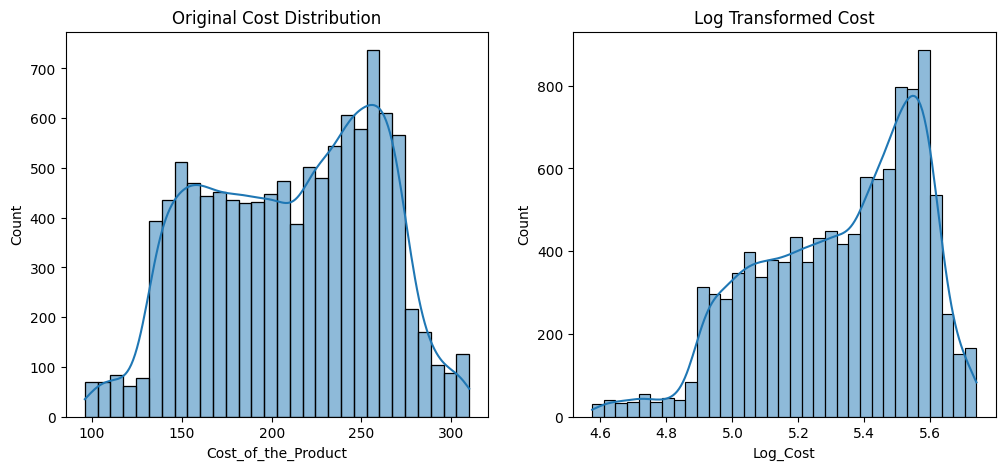

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(cluster_data["Cost_of_the_Product"], kde=True)
plt.title("Original Cost Distribution")

plt.subplot(1,2,2)
sns.histplot(cluster_data["Log_Cost"], kde=True)
plt.title("Log Transformed Cost")

plt.show()

In [ ]:
scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    cluster_data[["Log_Cost","Log_Discount"]]
)

In [ ]:
kmeans_model = KMeans(
    n_clusters=3,
    random_state=10
)

cluster_labels = kmeans_model.fit_predict(scaled_values)

cluster_data["Cluster_ID"] = cluster_labels

In [ ]:
for cluster in sorted(cluster_data["Cluster_ID"].unique()):

    print("\nCluster:", cluster)

    summary = cluster_data[cluster_data["Cluster_ID"] == cluster]

    print(summary.describe())


Cluster: 0
       Cost_of_the_Product  Discount_offered     Log_Cost  Log_Discount  \
count          3253.000000       3253.000000  3253.000000   3253.000000   
mean            159.640639          6.138026     5.068205      1.812972   
std              22.910415          3.939230     0.151293      0.572932   
min              96.000000          1.000000     4.574711      0.693147   
25%             144.000000          3.000000     4.976734      1.386294   
50%             161.000000          6.000000     5.087596      1.945910   
75%             178.000000          8.000000     5.187386      2.197225   
max             197.000000         32.000000     5.288267      3.496508   

       Cluster_ID  
count      3253.0  
mean          0.0  
std           0.0  
min           0.0  
25%           0.0  
50%           0.0  
75%           0.0  
max           0.0  

Cluster: 1
       Cost_of_the_Product  Discount_offered     Log_Cost  Log_Discount  \
count          5472.000000        5472.00000 

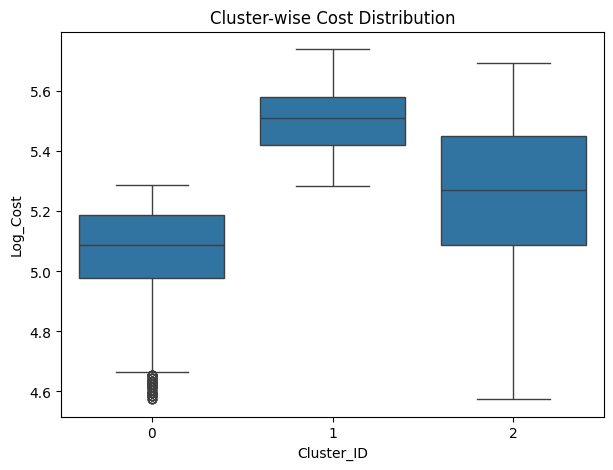

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=cluster_data,
    x="Cluster_ID",
    y="Log_Cost"
)

plt.title("Cluster-wise Cost Distribution")

plt.show()

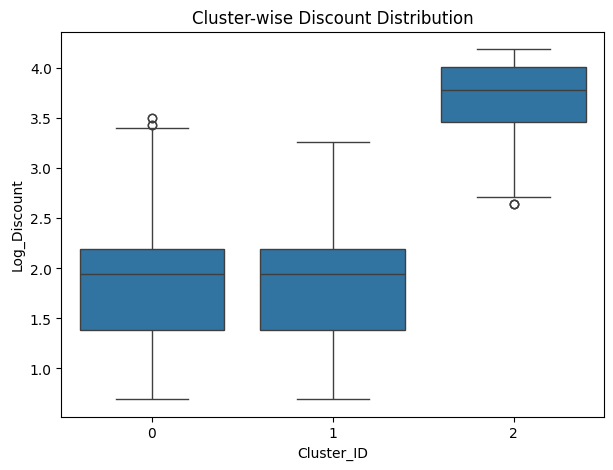

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=cluster_data,
    x="Cluster_ID",
    y="Log_Discount"
)

plt.title("Cluster-wise Discount Distribution")

plt.show()

In [ ]:
print("Cluster Center Coordinates:")

print(kmeans_model.cluster_centers_)

Cluster Center Coordinates:
[[-1.05170766 -0.40451863]
 [ 0.73302211 -0.43397416]
 [-0.25191049  1.62193698]]
